# Pre/Post Fusion Feature-Quality Analysis
Analyze per-Gaussian feature quality before and after view fusion using `fusion_data_<subject>.pt` dumped by the trainer.


## 1 · Configuration
Set the path below, or let the notebook auto-select the first matching dump file.


In [2]:
from pathlib import Path

FUSION_PATH = Path('../tmp/analysis/fusion_data_0007.pt')
OUT_DIR = Path('../tmp/analysis')

if not FUSION_PATH.exists():
    candidates = sorted(OUT_DIR.glob('fusion_data_*.pt'))
    if not candidates:
        raise FileNotFoundError('No fusion_data_*.pt found. Enable analysis.dump_local_feats and run training first.')
    FUSION_PATH = candidates[0]
    print(f'Auto-selected: {FUSION_PATH}')

SUBJECT = FUSION_PATH.stem.replace('fusion_data_', '')
print(f'Subject : {SUBJECT}')
print(f'File    : {FUSION_PATH.resolve()}')


Subject : 0007
File    : /root/autodl-tmp/work/avatar-benchmark/tmp/analysis/fusion_data_0007.pt


## 2 · Imports


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})



libgomp: Invalid value for environment variable OMP_NUM_THREADS


## 3 · Load tensors


In [4]:
data = torch.load(FUSION_PATH, map_location='cpu', weights_only=True)
pre = data['local_feats_prefusion'].float()      # (B, N, C)
w = data['view_weights'].float()                 # (B, N)
post = data['local_feats_postfusion'].float()    # (1, N, C)

B, N, C = pre.shape
print(f'Views (B)      : {B}')
print(f'Gaussians (N)  : {N}')
print(f'Channels (C)   : {C}')

w_sum = w.sum(dim=0, keepdim=True).clamp_min(1e-6)
post_recomputed = (pre * w.unsqueeze(-1)).sum(dim=0, keepdim=True) / w_sum.unsqueeze(-1)
max_abs_err = (post_recomputed - post).abs().max().item()
print(f'Max |recomputed-post|: {max_abs_err:.6e}')


Views (B)      : 4
Gaussians (N)  : 83632
Channels (C)   : 768
Max |recomputed-post|: 0.000000e+00


## 4 · Per-Gaussian quality metrics


In [5]:
# Weighted mean before fusion (should match post)
mu = post[0]                                  # (N, C)

# Weighted variance across views per Gaussian
diff = pre - mu.unsqueeze(0)                  # (B, N, C)
var = (w.unsqueeze(-1) * (diff ** 2)).sum(dim=0) / w_sum.squeeze(0).unsqueeze(-1)
std_per_gauss = torch.sqrt(var.mean(dim=-1) + 1e-12).numpy()

# View agreement: mean cosine similarity to fused descriptor
pre_n = torch.nn.functional.normalize(pre, dim=-1, eps=1e-6)
mu_n = torch.nn.functional.normalize(mu, dim=-1, eps=1e-6)
cos = (pre_n * mu_n.unsqueeze(0)).sum(dim=-1)  # (B, N)
cos_w = (cos * w).sum(dim=0) / w_sum.squeeze(0)
cos_w_np = cos_w.numpy()

# Fusion gain proxy: post norm vs average pre norm
post_norm = mu.norm(dim=-1).numpy()
pre_norm_mean = pre.norm(dim=-1).mean(dim=0).numpy()
gain = post_norm / np.clip(pre_norm_mean, 1e-8, None)

print(f'Weighted std across views: mean={std_per_gauss.mean():.4f}, median={np.median(std_per_gauss):.4f}')
print(f'Weighted cosine(pre,post): mean={cos_w_np.mean():.4f}, median={np.median(cos_w_np):.4f}')
print(f'Norm gain post/pre       : mean={gain.mean():.4f}, median={np.median(gain):.4f}')


Weighted std across views: mean=0.0051, median=0.0000
Weighted cosine(pre,post): mean=0.2833, median=0.0000
Norm gain post/pre       : mean=0.2827, median=0.0000


## 5 · Visual diagnostics


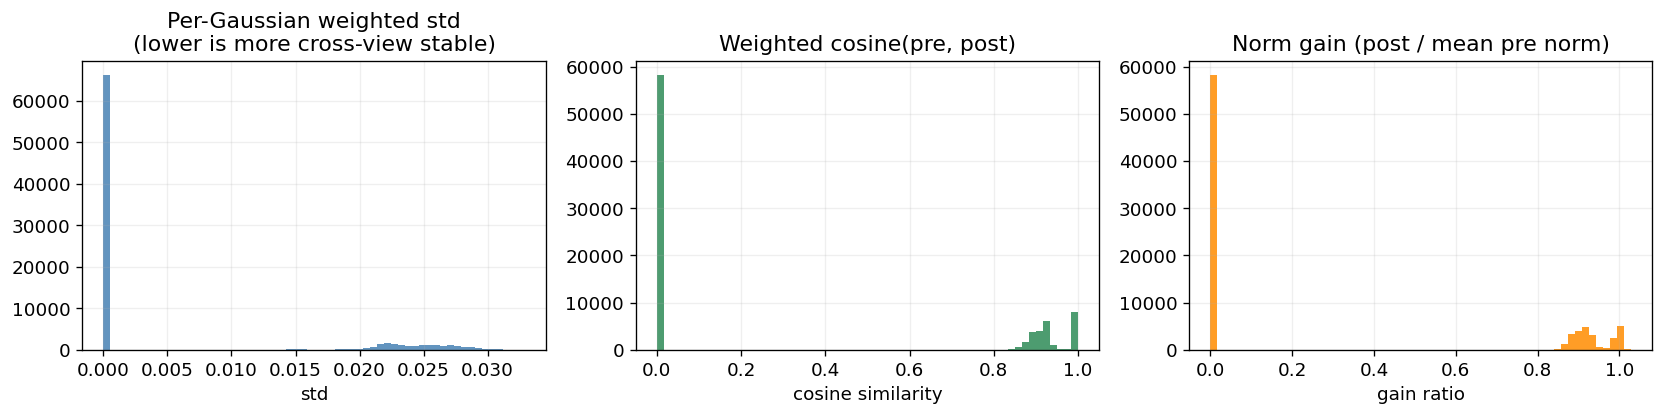

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

axes[0].hist(std_per_gauss, bins=60, color='steelblue', alpha=0.85)
axes[0].set_title('Per-Gaussian weighted std\n(lower is more cross-view stable)')
axes[0].set_xlabel('std')

axes[1].hist(cos_w_np, bins=60, color='seagreen', alpha=0.85)
axes[1].set_title('Weighted cosine(pre, post)')
axes[1].set_xlabel('cosine similarity')

axes[2].hist(gain, bins=60, color='darkorange', alpha=0.85)
axes[2].set_title('Norm gain (post / mean pre norm)')
axes[2].set_xlabel('gain ratio')

for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()


In [7]:
# Optional: inspect worst Gaussians by instability
k = min(20, N)
worst_idx = np.argsort(-std_per_gauss)[:k]
print('Top unstable gaussian indices:', worst_idx.tolist())
print('Their weighted cosine values  :', cos_w_np[worst_idx].round(4).tolist())


Top unstable gaussian indices: [32646, 32647, 32600, 32603, 74549, 32644, 74701, 74551, 74739, 74548, 32602, 32601, 74736, 32443, 74857, 32440, 74661, 32569, 74706, 74670]
Their weighted cosine values  : [0.8295000195503235, 0.8296999931335449, 0.8302000164985657, 0.830299973487854, 0.8305000066757202, 0.8303999900817871, 0.8305000066757202, 0.8307999968528748, 0.8310999870300293, 0.8314999938011169, 0.8314999938011169, 0.83160001039505, 0.8320000171661377, 0.8327999711036682, 0.8327000141143799, 0.833899974822998, 0.8346999883651733, 0.8349999785423279, 0.8353999853134155, 0.8356000185012817]
